# MNIST Logistic Regression with scikit-learn

## Project Overview

This project develops a multiclass logistic-regression workflow on the MNIST handwritten-digit dataset. The analysis moves from baseline classification to probability interpretation, coefficient visualization, nonlinear feature expansion, and manual reconstruction of class probabilities from the learned model parameters.

### What This Project Demonstrates

- Multiclass logistic regression
- Training and test accuracy
- Confusion-matrix analysis
- Learned coefficient visualization
- Class-probability prediction
- Quadratic feature expansion
- Linear and quadratic coefficient interpretation
- Manual computation of \(XW^T+b\)
- Softmax probability normalization
- Relationship between sigmoid and softmax

## 1. Environment and Data Preparation

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import time
from sklearn.linear_model import LogisticRegression


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

## 2. Baseline Multiclass Logistic Regression

A logistic-regression model is trained on the normalized 784-dimensional MNIST pixel representation. Performance is evaluated on both the training and test sets, followed by a class-level confusion matrix.

In [ ]:
model = LogisticRegression(n_jobs=-1)

start_train = time.time()
model.fit(x_train, y_train)
end_train = time.time()

print('Elapsed time training= {:.2f} secs'.format(end_train-start_train))

pred = model.predict(x_train)
accuracy = accuracy_score(y_train, pred)
print(f'Accuracy on training set {accuracy:.4}')

pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy on test set {accuracy:.4}')
print(confusion_matrix(y_test, pred))

# Preserve the baseline parameters for the manual probability reconstruction.
W_baseline = model.coef_
b_baseline = model.intercept_


Elapsed time training= 49.24 secs
Accuracy on training set 0.9346
Accuracy on test set 0.9256
[[ 959    0    0    3    1    7    5    4    1    0]
 [   0 1112    4    2    0    2    3    2   10    0]
 [   6    9  928   16    8    4   15    7   35    4]
 [   4    1   17  921    0   23    4   11   23    6]
 [   1    1    7    4  914    0   10    4   10   31]
 [  10    2    3   37    8  779   14    5   29    5]
 [   9    3    7    3    8   15  910    2    1    0]
 [   1    9   23    6    7    1    0  950    2   29]
 [   9   10    8   26    8   26   12    7  857   11]
 [   9    8    0   11   23    6    0   19    7  926]]


## 3. Interpreting the Learned Coefficients

For multiclass logistic regression, each digit class has its own coefficient vector. Reshaping each 784-element coefficient vector back to \(28\times28\) provides a visual interpretation of the pixel patterns associated with each class.

In [ ]:
w = model.coef_
print(w.shape)
b = model.intercept_
print(b.shape)

(10, 784)
(10,)


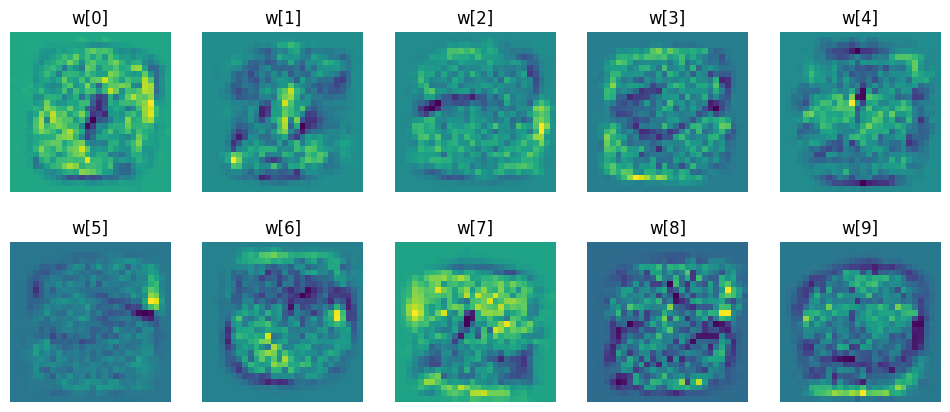

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(12,5))
for i in range(w.shape[0]):
  ax[i//5,i%5].imshow(w[i].reshape(28,28))
  ax[i//5,i%5].set_title(f'w[{i}]')
  ax[i//5,i%5].set_axis_off()


### Sample Class Predictions

In [ ]:
pred[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 6, 9], dtype=uint8)

## 4. Class Probabilities

`predict_proba()` returns one probability for each digit class. Taking the index of the largest probability produces the final class prediction.

In [ ]:
pred_prob = model.predict_proba(x_test)
pred = np.argmax(pred_prob,axis=1)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy on test set {accuracy:.4}')
print(confusion_matrix(y_test, pred))

Accuracy on test set 0.9256
[[ 959    0    0    3    1    7    5    4    1    0]
 [   0 1112    4    2    0    2    3    2   10    0]
 [   6    9  928   16    8    4   15    7   35    4]
 [   4    1   17  921    0   23    4   11   23    6]
 [   1    1    7    4  914    0   10    4   10   31]
 [  10    2    3   37    8  779   14    5   29    5]
 [   9    3    7    3    8   15  910    2    1    0]
 [   1    9   23    6    7    1    0  950    2   29]
 [   9   10    8   26    8   26   12    7  857   11]
 [   9    8    0   11   23    6    0   19    7  926]]


In [ ]:
np.set_printoptions(precision = 2,linewidth =140,suppress=True)
print(pred_prob[:10])

[[0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.99 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.99 0.01 0.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.98 0.   0.   0.   0.   0.02]
 [0.   0.99 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.   0.  ]
 [0.   0.02 0.   0.   0.   0.   0.   0.   0.   0.98]
 [0.   0.   0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.02 0.   0.   0.02 0.   0.96]]


### Comparing Predicted Probabilities with True Labels

In [ ]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

## 5. Quadratic Feature Expansion

The original normalized pixel values are concatenated with their squared values. This doubles the feature dimension and allows the logistic model to use both linear and quadratic pixel information.

In [ ]:
model2 = LogisticRegression(n_jobs=-1)
start_train = time.time()
model2.fit(np.hstack((x_train,x_train**2)),y_train)
end_train = time.time()
print('Elapsed time training= {:.2f} secs'.format(end_train-start_train))
pred = model2.predict(np.hstack((x_train,x_train**2)))
accuracy = accuracy_score(y_train, pred)
print(f'Accuracy on training set {accuracy:.4}')
pred = model2.predict(np.hstack((x_test,x_test**2)))
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy on test set {accuracy:.4}')
print(confusion_matrix(y_test, pred))

Elapsed time training= 57.10 secs
Accuracy on training set 0.9446
Accuracy on test set 0.9319
[[ 957    0    0    3    2    5    6    4    3    0]
 [   0 1119    4    1    0    3    3    1    4    0]
 [   5    7  941   13    8    4   11   11   29    3]
 [   4    0   17  928    2   20    3   12   17    7]
 [   1    1    7    3  915    0    8    9    8   30]
 [  11    2    6   36    9  772   14    8   26    8]
 [   8    3    9    0    7   16  909    2    4    0]
 [   1    7   24    4    8    2    0  952    2   28]
 [  10    7    6   19    6   11   11    6  890    8]
 [   5    9    0   13   18    7    0   16    5  936]]


### Model Parameters after Feature Expansion

The expanded model contains separate coefficient blocks for the original pixel features and the squared pixel features.

In [ ]:
w = model2.coef_
print(w.shape)
b = model2.intercept_
print(b.shape)

(10, 1568)
(10,)


### Coefficients for Original Pixel Features

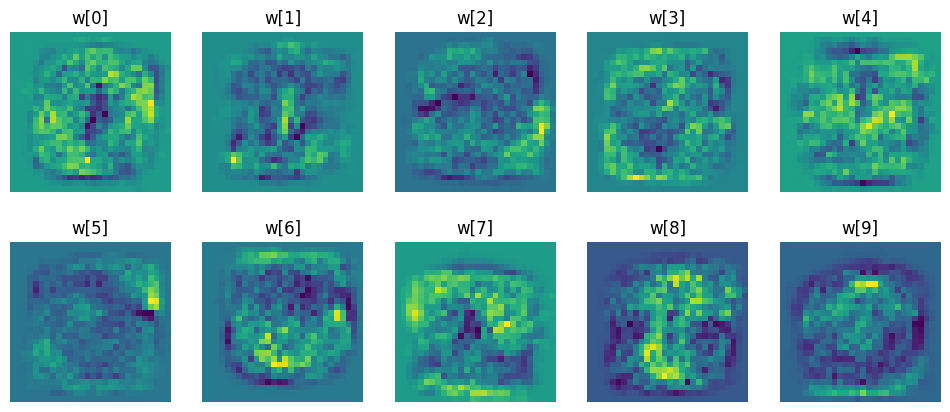

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(12,5))
for i in range(w.shape[0]):
  ax[i//5,i%5].imshow(w[i,:784].reshape(28,28))
  ax[i//5,i%5].set_title(f'w[{i}]')
  ax[i//5,i%5].set_axis_off()

### Coefficients for Quadratic Pixel Features

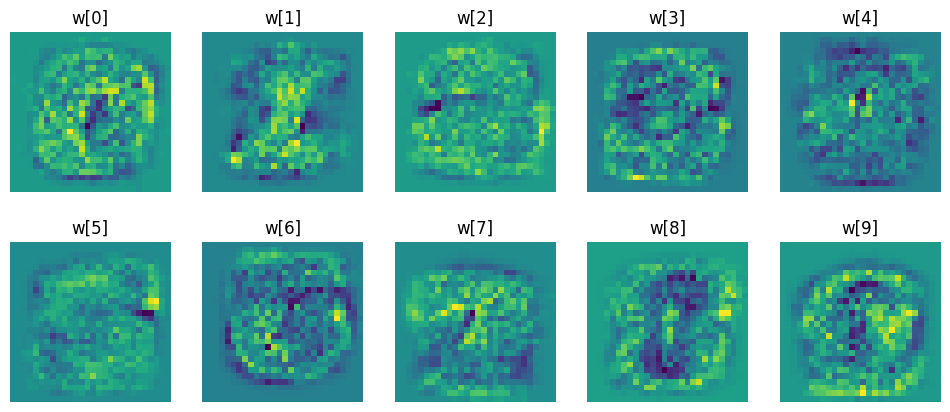

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(12,5))
for i in range(w.shape[0]):
  ax[i//5,i%5].imshow(w[i,784:].reshape(28,28))
  ax[i//5,i%5].set_title(f'w[{i}]')
  ax[i//5,i%5].set_axis_off()

## 6. Reconstructing Logistic Regression Predictions

The learned model can be evaluated directly from its parameters. For the test matrix \(X\), the class scores are computed from

\[
XW^T + b
\]

and then transformed into a probability distribution with softmax.

### Step-by-Step Score Normalization

Before wrapping the operation in a reusable function, the multiclass probability calculation can be inspected directly. The model first produces raw class scores, exponentiates them, and normalizes each row so the class probabilities sum to one.

In [ ]:
raw_scores = np.matmul(x_test, W_baseline.T) + b_baseline
exp_scores = np.exp(raw_scores)
normalized_scores = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

print('Raw score shape:', raw_scores.shape)
print('Probability shape:', normalized_scores.shape)
print('First probability vector:')
print(normalized_scores[0])
print('Probability sum:', np.sum(normalized_scores[0]))


### Inspecting Learned Parameter Shapes

The coefficient matrix contains one weight vector for each MNIST class, while the intercept contains one value per class.

In [ ]:
print('Coefficient shape:', W_baseline.shape)
print('Intercept shape:', b_baseline.shape)


In [ ]:
p = np.matmul(x_test, W_baseline.T) + b_baseline
s = np.exp(p)
s = s/np.sum(s,axis=1,keepdims=True)

In [ ]:
def softmax(x):
  s = np.exp(x)
  return s/np.sum(s,axis=1,keepdims=True)

### Manual Softmax Probabilities

In [ ]:
x = np.matmul(x_test, W_baseline.T) + b_baseline
p = softmax(x)

In [ ]:
p.shape

(10000, 10)

In [ ]:
manual_pred = np.argmax(p, axis=1)
accuracy = accuracy_score(y_test, manual_pred)
print(f'Accuracy on test set {accuracy:.4}')
print(confusion_matrix(y_test, manual_pred))

Accuracy on test set 0.9256
[[ 959    0    0    3    1    7    5    4    1    0]
 [   0 1112    4    2    0    2    3    2   10    0]
 [   6    9  928   16    8    4   15    7   35    4]
 [   4    1   17  921    0   23    4   11   23    6]
 [   1    1    7    4  914    0   10    4   10   31]
 [  10    2    3   37    8  779   14    5   29    5]
 [   9    3    7    3    8   15  910    2    1    0]
 [   1    9   23    6    7    1    0  950    2   29]
 [   9   10    8   26    8   26   12    7  857   11]
 [   9    8    0   11   23    6    0   19    7  926]]


In [ ]:
p[:10]

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.99, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.02],
       [0.  , 0.99, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.98],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.  , 0.02, 0.  , 0.96]])

## 7. Sigmoid and Softmax

Sigmoid is the probability link commonly associated with binary logistic regression. Softmax generalizes the idea to multiple mutually exclusive classes, which is the formulation used for MNIST.

### Vector and Batch Implementations

The one-dimensional softmax example is retained as a compact probability demonstration. The earlier `softmax()` implementation operates row-wise on a batch of model outputs, while `softmax_vector()` below operates on a single score vector.

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def softmax_vector(x):
  e_x = np.exp(x)
  return e_x / e_x.sum(axis=0)

print('sigmoid(3) =', sigmoid(3))
print('softmax([0, 3]) =', softmax_vector(np.array([0, 3])))


## 8. Comparative Results

| Model | Training Accuracy | Test Accuracy |
|---|---:|---:|
| Logistic regression with original pixels | 0.9346 | 0.9256 |
| Logistic regression with original + squared pixels | 0.9446 | 0.9319 |
| Manual softmax prediction from learned baseline parameters | — | 0.9256 |

The quadratic feature representation improves the saved test accuracy from **0.9256** to **0.9319**. The manually reconstructed softmax predictions reproduce the baseline model's test accuracy, confirming the relationship between the learned weights, class scores, and probabilities.

## 9. Key Findings

- Logistic regression provides both class predictions and class probabilities.
- The learned coefficient vectors can be reshaped and visualized as class-specific pixel patterns.
- Squared pixel features improve the saved MNIST test accuracy in this experiment.
- The model's predictions can be reconstructed directly from its learned weights and intercepts.
- Softmax converts multiclass linear scores into a normalized probability distribution.